In [99]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import operator
from dotenv import load_dotenv

In [100]:
load_dotenv()

True

In [101]:

model1 =  ChatGroq(
    model="llama-3.1-8b-instant"
)
model2 =  ChatGroq(
    model="openai/gpt-oss-120b"
)
model3 =  ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [102]:
generator_llm=model1
evaluator_llm=model2
optimizer_llm=model3

In [103]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [104]:
class Tweet(TypedDict):
    topic: str
    tweet: str
    feedback: str
    evaluation: Literal['approved','needs improvement']
    iteration: int
    max_iterations: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [105]:
def generator(state:Tweet):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]
    response=generator_llm.invoke(messages).content
    return {'tweet': response, 'tweet_history': [response]}

In [106]:
def evaluator(state:Tweet):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet']}"

    Use the criteria below to evaluate the tweet:

    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs_improvement"  
    - feedback: One paragraph explaining the strengths and weaknesses 
    """)
    ]
    structured_evaluator=evaluator_llm.with_structured_output(TweetEvaluation)
    response=structured_evaluator.invoke(messages)
    return {'feedback': response.feedback, 'evaluation': response.evaluation, 'feedback_history': [response.feedback]}
     

In [107]:
def optimizer(state:Tweet):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
    ]
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1
    return {'tweet': response,'iteration': iteration, 'tweet_history': [response]}

In [108]:
def route_evaluation(state:Tweet):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'needs_improvement'

In [109]:
graph= StateGraph(Tweet)
graph.add_node('generator',generator)
graph.add_node('evaluator',evaluator)
graph.add_node('optimizer',optimizer)

graph.add_edge(START, 'generator')
graph.add_edge('generator', 'evaluator')
graph.add_conditional_edges('evaluator',route_evaluation,{'approved': END, 'needs_improvement': 'optimizer'})
graph.add_edge('optimizer', 'evaluator')

In [110]:
workflow=graph.compile()

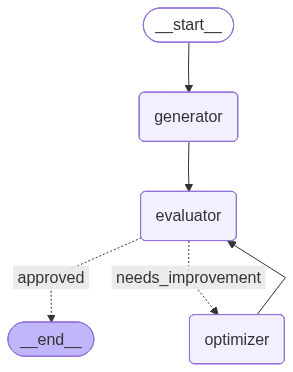

In [111]:
workflow

In [112]:
intial_state = {
    'topic': "Indian Railways",
    'iteration': 1,
    'max_iterations': 5
}
result=workflow.invoke(intial_state)

In [113]:
result

{'topic': 'Indian Railways',
 'tweet': '"Indian Railways: where \'on time\' is just a myth, \'delay\' is a way of life, and \'reserved\' means \'good luck finding a seat\' #IndianRailways #TrainLife"',
 'feedback': 'The tweet is concise enough for the platform and avoids a Q&A or classic setup‑punchline structure. It captures a familiar frustration with Indian Railways in a fresh enough phrasing, delivering a witty observation that can elicit a smile. While the theme isn’t brand‑new, the three‑part parallelism (“myth,” “way of life,” “good luck”) adds punch and makes it scroll‑stopping. The hashtags are relevant, boosting shareability, so it has solid virality potential among commuters and meme‑hunting audiences.',
 'evaluation': 'approved',
 'iteration': 1,
 'max_iterations': 5,
 'tweet_history': ['"Indian Railways: where \'on time\' is just a myth, \'delay\' is a way of life, and \'reserved\' means \'good luck finding a seat\' #IndianRailways #TrainLife"'],
 'feedback_history': ['The